# Lecture 11


## Install Pyspark


In [1]:
# Colab already has Java installed, so Spark can be installed easily with pip.
!pip install pyspark

In [2]:
import pyspark
print(pyspark.__file__)

/usr/local/lib/python3.12/dist-packages/pyspark/__init__.py


## Start a SparkSession
This will start a local Spark session.

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Lecture11").getOrCreate()
sc = spark.sparkContext

In [4]:
# import dependencies
import pyspark.sql.types as T
import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.ml.feature import Binarizer, Bucketizer, OneHotEncoder, VectorAssembler, StringIndexer, MinMaxScalerModel, \
StandardScaler, Imputer, Tokenizer,StopWordsRemover, MinMaxScaler, PolynomialExpansion
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans, KMeansModel
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator, ClusteringEvaluator, RegressionEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.mllib.evaluation import RankingMetrics
from random import randint
from pprint import pprint
import matplotlib.pyplot as plt
import numpy as np; import pandas as pd
from pyspark.ml.classification import DecisionTreeClassifier

## Decision Tree


### Data Collection

In [5]:
!gzip -d covtype.data.gz

In [6]:
#https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/
df = spark.read.csv(
    "covtype.data",
    inferSchema=True,
    header=False
)
df.show(5, truncate=False)

+----+---+---+---+---+----+---+---+---+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
|_c0 |_c1|_c2|_c3|_c4|_c5 |_c6|_c7|_c8|_c9 |_c10|_c11|_c12|_c13|_c14|_c15|_c16|_c17|_c18|_c19|_c20|_c21|_c22|_c23|_c24|_c25|_c26|_c27|_c28|_c29|_c30|_c31|_c32|_c33|_c34|_c35|_c36|_c37|_c38|_c39|_c40|_c41|_c42|_c43|_c44|_c45|_c46|_c47|_c48|_c49|_c50|_c51|_c52|_c53|_c54|
+----+---+---+---+---+----+---+---+---+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
|2596|51 |3  |258|0  |510 |221|232|148|6279|1   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0   |0

### Data Exploration

In [7]:
# display a shape of the data set
print(df.count(), len(df.columns))
df.show(3)

581012 55
+----+---+---+---+---+----+---+---+---+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
| _c0|_c1|_c2|_c3|_c4| _c5|_c6|_c7|_c8| _c9|_c10|_c11|_c12|_c13|_c14|_c15|_c16|_c17|_c18|_c19|_c20|_c21|_c22|_c23|_c24|_c25|_c26|_c27|_c28|_c29|_c30|_c31|_c32|_c33|_c34|_c35|_c36|_c37|_c38|_c39|_c40|_c41|_c42|_c43|_c44|_c45|_c46|_c47|_c48|_c49|_c50|_c51|_c52|_c53|_c54|
+----+---+---+---+---+----+---+---+---+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
|2596| 51|  3|258|  0| 510|221|232|148|6279|   1|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0| 

In [8]:
# check the data types
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- _c1: integer (nullable = true)
 |-- _c2: integer (nullable = true)
 |-- _c3: integer (nullable = true)
 |-- _c4: integer (nullable = true)
 |-- _c5: integer (nullable = true)
 |-- _c6: integer (nullable = true)
 |-- _c7: integer (nullable = true)
 |-- _c8: integer (nullable = true)
 |-- _c9: integer (nullable = true)
 |-- _c10: integer (nullable = true)
 |-- _c11: integer (nullable = true)
 |-- _c12: integer (nullable = true)
 |-- _c13: integer (nullable = true)
 |-- _c14: integer (nullable = true)
 |-- _c15: integer (nullable = true)
 |-- _c16: integer (nullable = true)
 |-- _c17: integer (nullable = true)
 |-- _c18: integer (nullable = true)
 |-- _c19: integer (nullable = true)
 |-- _c20: integer (nullable = true)
 |-- _c21: integer (nullable = true)
 |-- _c22: integer (nullable = true)
 |-- _c23: integer (nullable = true)
 |-- _c24: integer (nullable = true)
 |-- _c25: integer (nullable = true)
 |-- _c26: integer (nullable = true)
 |-- _

In [9]:
colnames = ["Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
            "Horizontal_Distance_To_Roadways",    "Hillshade_9am",    "Hillshade_Noon",    "Hillshade_3pm",
            "Horizontal_Distance_To_Fire_Points"] + [f"Wilderness_Area_{i}" for i in range(4)] + [f"Soil_Type_{i}" for i in range(40)] + ["Cover_Type"]
df = df.toDF(*[x.lower() for x in colnames])
df.show(5)

+---------+------+-----+--------------------------------+------------------------------+-------------------------------+-------------+--------------+-------------+----------------------------------+-----------------+-----------------+-----------------+-----------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+----------+
|elevation|aspect|slope|horizontal_distance_to_hydrology|vertical_distance_to_hydrology|horizontal_distance_to_roadways|hillshade_9am|hillshade_noon|hillshade_3pm|horizontal_distance_to_fire_points|wilderness

In [10]:
# Identifying the distinct values for cover_type
df.agg(F.collect_set('cover_type')).show(5, False)
# Find the number in each label
df.groupBy('cover_type').count().orderBy('count', ascending=False).show()

+-----------------------+
|collect_set(cover_type)|
+-----------------------+
|[1, 2, 3, 4, 5, 6, 7]  |
+-----------------------+

+----------+------+
|cover_type| count|
+----------+------+
|         2|283301|
|         1|211840|
|         3| 35754|
|         7| 20510|
|         6| 17367|
|         5|  9493|
|         4|  2747|
+----------+------+



### Data Preparation

In [ ]:
# no needs
#CONTINUOUS_COLUMNS = [x.lower() for x in ["Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
           # "Horizontal_Distance_To_Roadways",    "Hillshade_9am",    "Hillshade_Noon",    "Hillshade_3pm",
           # "Horizontal_Distance_To_Fire_Points"]]
#TARGET_COLUMN = ["cover_type"]
# The binary columns, containing binary features
#BINARY_COLUMNS = [x for x in df.columns if x not in CONTINUOUS_COLUMNS and x not in TARGET_COLUMN]
#len(CONTINUOUS_COLUMNS), len(BINARY_COLUMNS), len(TARGET_COLUMN)

### Modelling

In [12]:
train, test = df.randomSplit([0.9, 0.1],42)
train.cache()
print(train.count(), test.count())

522552 58460


In [14]:
for i in zip(train.groupBy('cover_type').count().collect(), test.groupBy('cover_type').count().collect()):
  #print(i) # (Row(cover_type=1, count=190633), Row(cover_type=1, count=21207))... )
  print(i[0]['cover_type'],i[0]['count']/train.count(), i[1]['count']/test.count())

1 0.36481154028689966 0.3627608621279507
6 0.029956827263124052 0.029302086897023606
3 0.06159004271345244 0.06106739651043448
5 0.01636966273213001 0.016062264796442013
4 0.00468661492062034 0.005097502565856996
7 0.03526347617079257 0.03563120082107424
2 0.4873218359129809 0.4900786862812179


In [15]:
train.show(3)

+---------+------+-----+--------------------------------+------------------------------+-------------------------------+-------------+--------------+-------------+----------------------------------+-----------------+-----------------+-----------------+-----------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+----------+
|elevation|aspect|slope|horizontal_distance_to_hydrology|vertical_distance_to_hydrology|horizontal_distance_to_roadways|hillshade_9am|hillshade_noon|hillshade_3pm|horizontal_distance_to_fire_points|wilderness

In [16]:
vector_assembler = VectorAssembler(inputCols=df.columns[:-1], outputCol="featureVector")
assembled_train_data = vector_assembler.transform(train)
assembled_train_data.select("featureVector").show(truncate=False)

+----------------------------------------------------------------------------------------------------+
|featureVector                                                                                       |
+----------------------------------------------------------------------------------------------------+
|(54,[0,1,2,3,4,5,6,7,8,9,13,15],[1859.0,18.0,12.0,67.0,11.0,90.0,211.0,215.0,139.0,792.0,1.0,1.0])  |
|(54,[0,1,2,3,4,5,6,7,8,9,13,15],[1860.0,18.0,13.0,95.0,15.0,90.0,210.0,213.0,138.0,780.0,1.0,1.0])  |
|(54,[0,1,2,3,4,5,6,7,8,9,13,15],[1861.0,35.0,14.0,60.0,11.0,85.0,218.0,209.0,124.0,832.0,1.0,1.0])  |
|(54,[0,1,2,3,4,5,6,7,8,9,13,15],[1863.0,37.0,17.0,120.0,18.0,90.0,217.0,202.0,115.0,769.0,1.0,1.0]) |
|(54,[0,1,2,3,4,5,6,7,8,9,13,15],[1866.0,23.0,14.0,85.0,16.0,108.0,212.0,210.0,133.0,819.0,1.0,1.0]) |
|(54,[0,1,2,3,4,5,6,7,8,9,13,15],[1867.0,20.0,15.0,108.0,19.0,120.0,208.0,206.0,132.0,808.0,1.0,1.0])|
|(54,[0,1,2,3,4,5,6,7,8,9,13,18],[1871.0,22.0,22.0,60.0,12.0,85.0,200.0,1

In [18]:
from pyspark.ml.classification import DecisionTreeClassifier

classifier = DecisionTreeClassifier(seed=42,
                                    labelCol="cover_type",
                                    featuresCol="featureVector",
                                    predictionCol="prediction")

model = classifier.fit(assembled_train_data)
# shows some of its tree structure
print(model.toDebugString)

DecisionTreeClassificationModel: uid=DecisionTreeClassifier_e80016c9427a, depth=5, numNodes=51, numClasses=8, numFeatures=54
  If (feature 0 <= 3051.5)
   If (feature 0 <= 2557.5)
    If (feature 10 <= 0.5)
     If (feature 0 <= 2456.5)
      If (feature 3 <= 15.0)
       Predict: 4.0
      Else (feature 3 > 15.0)
       Predict: 3.0
     Else (feature 0 > 2456.5)
      If (feature 17 <= 0.5)
       Predict: 2.0
      Else (feature 17 > 0.5)
       Predict: 3.0
    Else (feature 10 > 0.5)
     If (feature 9 <= 5109.5)
      Predict: 2.0
     Else (feature 9 > 5109.5)
      If (feature 5 <= 562.0)
       Predict: 2.0
      Else (feature 5 > 562.0)
       Predict: 5.0
   Else (feature 0 > 2557.5)
    If (feature 0 <= 2958.5)
     If (feature 15 <= 0.5)
      If (feature 17 <= 0.5)
       Predict: 2.0
      Else (feature 17 > 0.5)
       Predict: 3.0
     Else (feature 15 > 0.5)
      Predict: 3.0
    Else (feature 0 > 2958.5)
     If (feature 3 <= 211.0)
      If (feature 36 <= 0.5)
    

In [19]:
len(model.featureImportances.toArray()) # 54

54

In [ ]:
len(df.columns) # 55

55

In [20]:
pd.DataFrame(model.featureImportances.toArray(),
             index=df.columns[:-1],
             columns=['importance']).sort_values(by="importance", ascending=False)

,importance
elevation,0.795971
horizontal_distance_to_hydrology,0.039419
soil_type_3,0.031041
wilderness_area_0,0.028751
soil_type_31,0.027728
hillshade_noon,0.025322
soil_type_1,0.024603
wilderness_area_2,0.011446
horizontal_distance_to_roadways,0.006242
soil_type_22,0.006089


In [21]:
result = model.transform(assembled_train_data)
# The vector contains probabilities for outcomes 1 to 7 at indices 1 to 7. However, index 0 always shows
# a probability of 0.0, which is not a valid outcome. This quirk should be noted when interpreting the vector.
result.select("cover_type", "probability", "prediction").show(3, truncate=False)

+----------+----------------------------------------------------------------------------------------------+----------+
|cover_type|probability                                                                                   |prediction|
+----------+----------------------------------------------------------------------------------------------+----------+
|3         |[0.0,0.0,0.0359275376986135,0.6289174510002361,0.04888169213642344,0.0,0.2862733191647269,0.0]|3.0       |
|3         |[0.0,0.0,0.0359275376986135,0.6289174510002361,0.04888169213642344,0.0,0.2862733191647269,0.0]|3.0       |
|3         |[0.0,0.0,0.0359275376986135,0.6289174510002361,0.04888169213642344,0.0,0.2862733191647269,0.0]|3.0       |
+----------+----------------------------------------------------------------------------------------------+----------+
only showing top 3 rows


In [22]:
result.show(3)
len(result.columns)

+---------+------+-----+--------------------------------+------------------------------+-------------------------------+-------------+--------------+-------------+----------------------------------+-----------------+-----------------+-----------------+-----------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+----------+--------------------+--------------------+--------------------+----------+
|elevation|aspect|slope|horizontal_distance_to_hydrology|vertical_distance_to_hydrology|horizontal_distance_to_roadways|hillshade_9am|

59

In [ ]:
# alternatively, using pipeline model
df_pipeline = Pipeline(stages=[vector_assembler, classifier])
df_pipeline_model = df_pipeline.fit(train) # notice that the pipeline work on train data
result = df_pipeline_model.transform(test) # notice that the pipeline can work on test data
result.select("cover_type", "probability", "prediction").show(3, False)

+----------+----------------------------------------------------------------------------------------------+----------+
|cover_type|probability                                                                                   |prediction|
+----------+----------------------------------------------------------------------------------------------+----------+
|3         |[0.0,0.0,0.0359275376986135,0.6289174510002361,0.04888169213642344,0.0,0.2862733191647269,0.0]|3.0       |
|6         |[0.0,0.0,0.0359275376986135,0.6289174510002361,0.04888169213642344,0.0,0.2862733191647269,0.0]|3.0       |
|6         |[0.0,0.0,0.0359275376986135,0.6289174510002361,0.04888169213642344,0.0,0.2862733191647269,0.0]|3.0       |
+----------+----------------------------------------------------------------------------------------------+----------+
only showing top 3 rows



In [ ]:
# get the decision tree model from last stage of the pipeline
dt_model =  df_pipeline_model.stages[-1]
pd.DataFrame(dt_model.featureImportances.toArray(),
             index=df.columns[:-1],
             columns=['importance']).sort_values(by="importance", ascending=False)

,importance
elevation,0.795971
horizontal_distance_to_hydrology,0.039419
soil_type_3,0.031041
wilderness_area_0,0.028751
soil_type_31,0.027728
hillshade_noon,0.025322
soil_type_1,0.024603
wilderness_area_2,0.011446
horizontal_distance_to_roadways,0.006242
soil_type_22,0.006089


### Evaluation

In [23]:
confusion_matrix = result.groupBy("cover_type") \
    .pivot("prediction", range(1, 8)) \
    .count() \
    .na.fill(0.0) \
    .orderBy("cover_type")

confusion_matrix.show()

+----------+------+------+-----+---+---+---+----+
|cover_type|     1|     2|    3|  4|  5|  6|   7|
+----------+------+------+-----+---+---+---+----+
|         1|118226| 69042|  157|  0|  0|  0|3208|
|         2| 36870|212633| 4413|104| 90|  0| 541|
|         3|     0|  5417|26112|655|  0|  0|   0|
|         4|     0|    22| 1449|978|  0|  0|   0|
|         5|     2|  7678|  742|  0|132|  0|   0|
|         6|     0|  5878| 9189|587|  0|  0|   0|
|         7|  9832|   293|   58|  0|  0|  0|8244|
+----------+------+------+-----+---+---+---+----+



In [24]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# note that MulticlassClassificationEvaluator provides aggregate metrics
evaluator = MulticlassClassificationEvaluator(labelCol="cover_type", predictionCol="prediction")

evaluator.setMetricName("accuracy")
accuracy = evaluator.evaluate(result)
print("Accuracy:", accuracy)

evaluator.setMetricName("f1")
f1_score = evaluator.evaluate(result)
print("F1 Score:", f1_score)

Accuracy: 0.7010307108192103
F1 Score: 0.6804119873829173


In [25]:
from pyspark.mllib.evaluation import MulticlassMetrics

# Convert the DataFrame to an RDD of (prediction, label) tuples
predictionAndLabels = result.select("prediction", "cover_type").rdd.map(lambda row: (float(row.prediction), float(row.cover_type)))

# Instantiate MulticlassMetrics
metrics = MulticlassMetrics(predictionAndLabels)

# Compute precision and recall for each label
for label in range(1, 8):
    precision = metrics.precision(label)
    recall = metrics.recall(label)
    print(f"Label {label}: Precision = {precision}, Recall = {recall}")

/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Label 1: Precision = 0.7168253198326563, Recall = 0.6201759401572655
Label 2: Precision = 0.7065087735037198, Recall = 0.8349977027382575
Label 3: Precision = 0.6199430199430199, Recall = 0.8113348247576435
Label 4: Precision = 0.4208261617900172, Recall = 0.3993466721110657
Label 5: Precision = 0.5945945945945946, Recall = 0.015431377133504794
Label 6: Precision = 0.0, Recall = 0.0
Label 7: Precision = 0.6874009839072792, Recall = 0.44738698648721986


In [27]:
print(metrics.weightedFMeasure()) # 0.6804119873829173 (same as above)
print(metrics.weightedPrecision) # 0.6799313300759465
print(metrics.weightedRecall) # 0.7010307108192104

0.6804119873829173
0.6799313300759465
0.7010307108192104


### Improvement

In [ ]:
def calculate_class_weights(df):
    # Calculate total number of instances
    total_samples = df.count()

    # Calculate class frequencies
    class_frequencies = df.groupBy("cover_type").count()
    class_frequencies.show()
    class_frequencies_dict = {row["cover_type"]: row["count"] for row in class_frequencies.collect()}

    # Calculate class weights
    class_weights = {}
    for class_label, class_count in class_frequencies_dict.items():
        class_weights[class_label] = total_samples / class_count if class_count != 0 else 0.0

    # Normalize weights
    total_weight = sum(class_weights.values())
    class_weights_normalized = {cls: weight / total_weight for cls, weight in class_weights.items()}

    return class_weights_normalized

class_weights = calculate_class_weights(train)
print(class_weights)


+----------+------+
|cover_type| count|
+----------+------+
|         1|190633|
|         6| 15654|
|         3| 32184|
|         5|  8554|
|         4|  2449|
|         7| 18427|
|         2|254651|
+----------+------+

{1: 0.0076732993459412945, 6: 0.09344474729876241, 3: 0.045450661018357784, 5: 0.1710058538946489, 4: 0.5972985194833919, 7: 0.07938264905925146, 2: 0.005744269899646288}


In [ ]:
from pyspark.sql.functions import when

# Add a new column 'class_weights_column' with the corresponding class weights
weighted_train = train.withColumn("class_weights_column",
                           when(train["cover_type"] == 1, class_weights[1])
                           .when(train["cover_type"] == 2, class_weights[2])
                           .when(train["cover_type"] == 3, class_weights[3])
                           .when(train["cover_type"] == 4, class_weights[4])
                           .when(train["cover_type"] == 5, class_weights[5])
                           .when(train["cover_type"] == 6, class_weights[6])
                           .when(train["cover_type"] == 7, class_weights[7])
                           .otherwise(0.0))  # Default value if cover_type does not match any key in class_weights

In [ ]:
# List of columns excluding 'cover_type'
columns_to_assemble = [col for col in df.columns if col != 'cover_type']
vector_assembler = VectorAssembler(inputCols=columns_to_assemble, outputCol="featureVector")

classifier = DecisionTreeClassifier(seed=42,
                                    labelCol="cover_type",
                                    featuresCol="featureVector",
                                    predictionCol="prediction",
                                    weightCol="class_weights_column")

df_pipeline = Pipeline(stages=[vector_assembler, classifier])

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# impurity - Add different values for the impurity criterion ("gini" or "entropy")
# maxDepth - Test two different maximum depths for the tree (shallow = 1, deep = 20)
# Try different maximum numbers of bins for discretizing continuous features (affects feature splits)
# Explore different thresholds for minimum information gain required to split a node
paramGrid = ParamGridBuilder() \
    .addGrid(classifier.impurity, ["gini", "entropy"]) \
    .addGrid(classifier.maxDepth, [1, 20]) \
    .addGrid(classifier.maxBins, [40, 300]) \
    .addGrid(classifier.minInfoGain, [0.0, 0.05]) \
    .build()

multiclassEval = MulticlassClassificationEvaluator() \
    .setLabelCol("cover_type") \
    .setPredictionCol("prediction") \
    .setMetricName("f1")

In [ ]:
from pyspark.ml.tuning import TrainValidationSplit

validator = TrainValidationSplit(
    seed=42,
    estimator=df_pipeline,
    evaluator=multiclassEval,
    estimatorParamMaps=paramGrid,
    trainRatio=0.9
)

validator_model = validator.fit(weighted_train)

In [ ]:
# explore the accuracy that each of the modelsachieved for each combination of hyperparameters.

# Get validation metrics and estimator parameter maps from the validator model
metrics = validator_model.validationMetrics
params = validator_model.getEstimatorParamMaps()

# Zip metrics and params into a list of tuples
metrics_and_params = list(zip(metrics, params))

# Sort the list of tuples based on metrics in descending order
metrics_and_params.sort(key=lambda x: x[0], reverse=True)

# Display the sorted list
metrics_and_params

[(0.8965388327446692,
  {Param(parent='DecisionTreeClassifier_cafa9a01860a', name='impurity', doc='Criterion used for information gain calculation (case-insensitive). Supported options: entropy, gini'): 'entropy',
   Param(parent='DecisionTreeClassifier_cafa9a01860a', name='maxDepth', doc='Maximum depth of the tree. (>= 0) E.g., depth 0 means 1 leaf node; depth 1 means 1 internal node + 2 leaf nodes. Must be in range [0, 30].'): 20,
   Param(parent='DecisionTreeClassifier_cafa9a01860a', name='maxBins', doc='Max number of bins for discretizing continuous features.  Must be >=2 and >= number of categories for any categorical feature.'): 300,
   Param(parent='DecisionTreeClassifier_cafa9a01860a', name='minInfoGain', doc='Minimum information gain for a split to be considered at a tree node.'): 0.0}),
 (0.8938368172853642,
  {Param(parent='DecisionTreeClassifier_cafa9a01860a', name='impurity', doc='Criterion used for information gain calculation (case-insensitive). Supported options: entrop

In [ ]:
# The result of the validator contains the best model it found. This itself is a representation of the best overall
# pipeline it found

from pprint import pprint

# Retrieve the best model from the validator model
best_model = validator_model.bestModel

# Print the parameter map of the second stage of the best model
pprint(best_model.stages[1].extractParamMap())

{Param(parent='DecisionTreeClassifier_cafa9a01860a', name='weightCol', doc='weight column name. If this is not set or empty, we treat all instance weights as 1.0.'): 'class_weights_column',
 Param(parent='DecisionTreeClassifier_cafa9a01860a', name='seed', doc='random seed.'): 42,
 Param(parent='DecisionTreeClassifier_cafa9a01860a', name='impurity', doc='Criterion used for information gain calculation (case-insensitive). Supported options: entropy, gini'): 'entropy',
 Param(parent='DecisionTreeClassifier_cafa9a01860a', name='maxDepth', doc='Maximum depth of the tree. (>= 0) E.g., depth 0 means 1 leaf node; depth 1 means 1 internal node + 2 leaf nodes. Must be in range [0, 30].'): 20,
 Param(parent='DecisionTreeClassifier_cafa9a01860a', name='minWeightFractionPerNode', doc='Minimum fraction of the weighted sample count that each child must have after split. If a split causes the fraction of the total weight in the left or right child to be less than minWeightFractionPerNode, the split wi

In [ ]:
# Evaluate the best model using the MulticlassClassificationEvaluator
# best_Model is a complete pipeline
evaluation_result = multiclassEval.evaluate(best_model.transform(test))
# Display the F1 score from evaluation_result
print(multiclassEval.getMetricName()) # f1
evaluation_result

f1


0.9046986950364206

In [ ]:
result = best_model.transform(test)
result.select("cover_type", "probability", "prediction").show(3, False)

+----------+---------------------------------+----------+
|cover_type|probability                      |prediction|
+----------+---------------------------------+----------+
|3         |[0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0]|3.0       |
|6         |[0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0]|3.0       |
|6         |[0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0]|6.0       |
+----------+---------------------------------+----------+
only showing top 3 rows



In [ ]:
confusion_matrix = result.groupBy("cover_type") \
    .pivot("prediction", range(1, 8)) \
    .count() \
    .na.fill(0.0) \
    .orderBy("cover_type")

confusion_matrix.show()

+----------+-----+-----+----+---+---+----+----+
|cover_type|    1|    2|   3|  4|  5|   6|   7|
+----------+-----+-----+----+---+---+----+----+
|         1|19433| 1426|   2|  0| 89|   4| 253|
|         2| 2186|25526| 101|  0|677| 142|  18|
|         3|    2|   69|3221| 32| 10| 236|   0|
|         4|    0|    0|  46|243|  0|   9|   0|
|         5|    9|   69|  12|  0|845|   4|   0|
|         6|    1|   55| 119|  8|  4|1526|   0|
|         7|   72|   13|   0|  0|  0|   0|1998|
+----------+-----+-----+----+---+---+----+----+



In [ ]:
from pyspark.mllib.evaluation import MulticlassMetrics

# Convert the DataFrame to an RDD of (prediction, label) tuples
predictionAndLabels = result.select("prediction", "cover_type").rdd.map(lambda row: (float(row.prediction), float(row.cover_type)))

# Instantiate MulticlassMetrics
metrics = MulticlassMetrics(predictionAndLabels)

# Compute precision and recall for each label
for label in range(1, 8):
    precision = metrics.precision(label)
    recall = metrics.recall(label)
    print(f"Label {label}: Precision = {precision}, Recall = {recall}")
# averaged across classes, weighted by the number of true instances in each class
print(metrics.weightedPrecision) # 0.909012076598765
print(metrics.weightedRecall) # 0.9030448169688675

/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Label 1: Precision = 0.895406165046307, Recall = 0.9163483755363795
Label 2: Precision = 0.939907209661978, Recall = 0.8909598603839441
Label 3: Precision = 0.9200228506141103, Recall = 0.9022408963585434
Label 4: Precision = 0.8586572438162544, Recall = 0.8154362416107382
Label 5: Precision = 0.52, Recall = 0.8998935037273695
Label 6: Precision = 0.7943779281624154, Recall = 0.8908347927612376
Label 7: Precision = 0.880564125165271, Recall = 0.9591934709553529
0.909012076598765
0.9030448169688675


In [ ]:
# get the decision tree model from last stage of the pipeline
pd.DataFrame(best_model.stages[1].featureImportances.toArray(),
             index=df.columns[:-1],
             columns=['importance']).sort_values(by="importance", ascending=False)

,importance
elevation,0.560822
horizontal_distance_to_roadways,0.082415
horizontal_distance_to_fire_points,0.077078
horizontal_distance_to_hydrology,0.049124
hillshade_9am,0.035741
vertical_distance_to_hydrology,0.024512
hillshade_noon,0.020431
aspect,0.019856
wilderness_area_2,0.017009
wilderness_area_0,0.016653


## Random Forest
The dataset is from machine-learning-with-pyspark book.

In [28]:
df = spark.read.csv(
    "affairs.csv",
    inferSchema=True,
    header=True
)

df.printSchema()
df.describe().show()
print(df.count(), len(df.columns))
df.show(3)

root
 |-- rate_marriage: integer (nullable = true)
 |-- age: double (nullable = true)
 |-- yrs_married: double (nullable = true)
 |-- children: double (nullable = true)
 |-- religious: integer (nullable = true)
 |-- affairs: integer (nullable = true)

+-------+------------------+------------------+-----------------+------------------+------------------+------------------+
|summary|     rate_marriage|               age|      yrs_married|          children|         religious|           affairs|
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+
|  count|              6366|              6366|             6366|              6366|              6366|              6366|
|   mean| 4.109644989004084|29.082862079798932| 9.00942507068803|1.3968740182218033|2.4261702796104303|0.3224945020420987|
| stddev|0.9614295945655025| 6.847881883668817|7.280119972766412| 1.433470828560344|0.8783688402641785| 0.467467779921086|
|    min| 

In [41]:
df.count(), len(df.columns)

(6366, 6)

In [29]:
df.groupBy('affairs').count().show()

+-------+-----+
|affairs|count|
+-------+-----+
|      1| 2053|
|      0| 4313|
+-------+-----+



In [30]:
df.groupBy('rate_marriage').count().show()

+-------------+-----+
|rate_marriage|count|
+-------------+-----+
|            1|   99|
|            3|  993|
|            5| 2684|
|            4| 2242|
|            2|  348|
+-------------+-----+



In [31]:
df.groupBy('children').count().show()

+--------+-----+
|children|count|
+--------+-----+
|     0.0| 2414|
|     1.0| 1159|
|     4.0|  328|
|     3.0|  781|
|     2.0| 1481|
|     5.5|  203|
+--------+-----+



In [32]:
df.groupBy('religious').count().show()

+---------+-----+
|religious|count|
+---------+-----+
|        1| 1021|
|        3| 2422|
|        4|  656|
|        2| 2267|
+---------+-----+



In [33]:
# if marriage rating is related to the affairs variable or not:
df.groupBy('rate_marriage','affairs').count().orderBy('rate_marriage','affairs','count',ascending=True).show()

+-------------+-------+-----+
|rate_marriage|affairs|count|
+-------------+-------+-----+
|            1|      0|   25|
|            1|      1|   74|
|            2|      0|  127|
|            2|      1|  221|
|            3|      0|  446|
|            3|      1|  547|
|            4|      0| 1518|
|            4|      1|  724|
|            5|      0| 2197|
|            5|      1|  487|
+-------------+-------+-----+



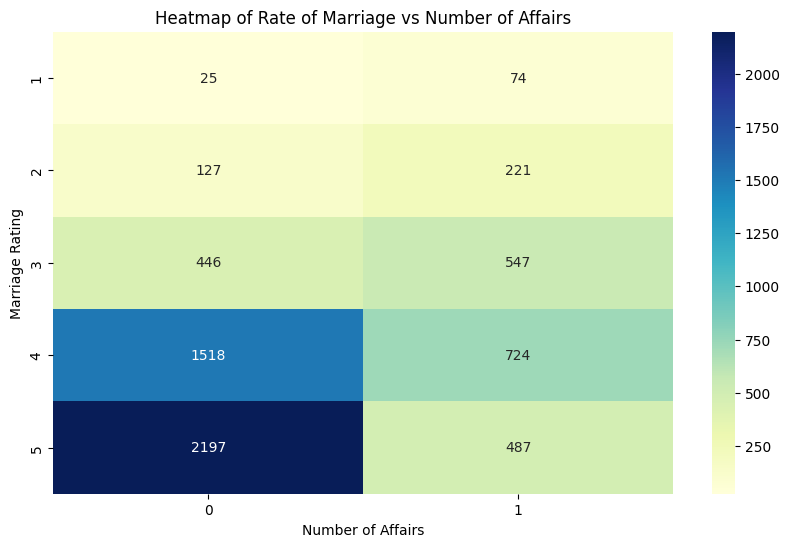

In [35]:
# Convert to Pandas DataFrame (after sorting is optional)
pdf = df.groupBy('rate_marriage','affairs').count().orderBy('rate_marriage', 'affairs').toPandas()

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Pivot table for heatmap
pivot_table = pdf.pivot(index='rate_marriage', columns='affairs', values='count').fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap of Rate of Marriage vs Number of Affairs")
plt.ylabel("Marriage Rating")
plt.xlabel("Number of Affairs")
plt.show()

In [37]:
numeric_cols = ["rate_marriage", "age", "yrs_married", "children", "religious", "affairs"]
df_numeric = df.select(numeric_cols)
pdf = df_numeric.toPandas()

corr_matrix = pdf.corr()
print(corr_matrix)

               rate_marriage       age  yrs_married  children  religious  \
rate_marriage       1.000000 -0.111127    -0.128978 -0.129161   0.078794   
age                -0.111127  1.000000     0.894082  0.673902   0.136598   
yrs_married        -0.128978  0.894082     1.000000  0.772806   0.132683   
children           -0.129161  0.673902     0.772806  1.000000   0.141845   
religious           0.078794  0.136598     0.132683  0.141845   1.000000   
affairs            -0.331776  0.146519     0.203109  0.159833  -0.129299   

                affairs  
rate_marriage -0.331776  
age            0.146519  
yrs_married    0.203109  
children       0.159833  
religious     -0.129299  
affairs        1.000000  


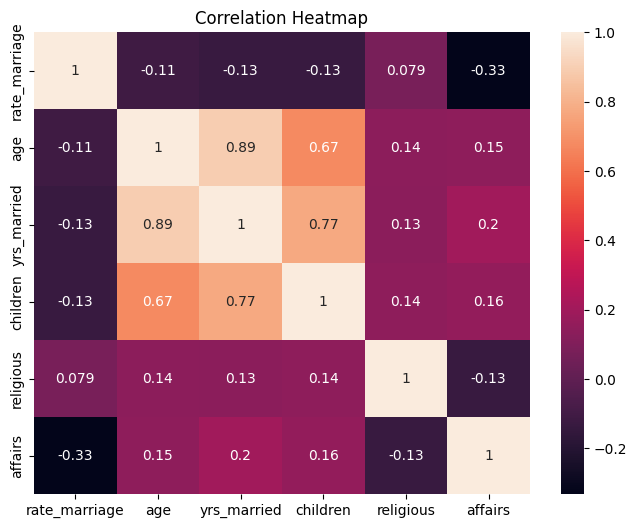

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [39]:
df.groupBy('affairs').mean().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------+
|affairs|avg(rate_marriage)|          avg(age)|  avg(yrs_married)|     avg(children)|    avg(religious)|avg(affairs)|
+-------+------------------+------------------+------------------+------------------+------------------+------------+
|      1|3.6473453482708234|30.537018996590355|11.152459814905017|1.7289332683877252| 2.261568436434486|         1.0|
|      0| 4.329700904242986| 28.39067934152562| 7.989334569904939|1.2388128912589844|2.5045212149316023|         0.0|
+-------+------------------+------------------+------------------+------------------+------------------+------------+



In [ ]:
train, test= df.randomSplit([0.75,0.25])
print(train.count(), test.count())
train.groupBy('affairs').count().show()
test.groupBy('affairs').count().show()

4728 1638
+-------+-----+
|affairs|count|
+-------+-----+
|      1| 1553|
|      0| 3175|
+-------+-----+

+-------+-----+
|affairs|count|
+-------+-----+
|      1|  500|
|      0| 1138|
+-------+-----+



In [ ]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

vector_assembler = VectorAssembler(inputCols=['rate_marriage', 'age','yrs_married', 'children', 'religious'], outputCol="featureVector")

rf_classifier = RandomForestClassifier(
    labelCol="affairs",
    featuresCol="featureVector",
    predictionCol="prediction",
)

df_pipeline = Pipeline(stages=[vector_assembler, rf_classifier])
#df_pipeline_model = df_pipeline.fit(train)
#result = df_pipeline_model.transform(test)
#result.select("affairs", "probability", "prediction").show(3, False)


In [ ]:
paramGrid = ParamGridBuilder()\
  .addGrid(rf_classifier.numTrees,[5,10,20,25,30,40,50])\
  .addGrid(rf_classifier.maxDepth,[2,3,5,6,8,9,10])\
  .build()

evaluator=BinaryClassificationEvaluator(rawPredictionCol='rawPrediction',labelCol='affairs')

In [ ]:
validator = CrossValidator(estimator=df_pipeline, estimatorParamMaps=paramGrid, evaluator=evaluator, numFolds=3)
validator_model = validator.fit(train)

In [ ]:
result = validator_model.transform(test)
result.select("affairs", "probability", "prediction").show(3, False)

+-------+----------------------------------------+----------+
|affairs|probability                             |prediction|
+-------+----------------------------------------+----------+
|0      |[0.8581362961615528,0.1418637038384471] |0.0       |
|1      |[0.34535769407215744,0.6546423059278426]|1.0       |
|0      |[0.37161075551148637,0.6283892444885136]|1.0       |
+-------+----------------------------------------+----------+
only showing top 3 rows



In [ ]:
confusion_matrix = result.groupBy("affairs") \
    .pivot("prediction", range(2)) \
    .count() \
    .na.fill(0.0) \
    .orderBy("affairs")

confusion_matrix.show()

+-------+---+---+
|affairs|  0|  1|
+-------+---+---+
|      0|997|141|
|      1|312|188|
+-------+---+---+



In [ ]:
# Evaluate the best model
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
rf_auc=BinaryClassificationEvaluator(labelCol='affairs').evaluate(result)
print(rf_auc)
rf_f1=MulticlassClassificationEvaluator(labelCol='affairs',metricName='f1').evaluate(result)
print(rf_f1)

0.7344543057996484
0.7045832778008707


In [ ]:
# Retrieve the best model from the validator model
best_model = validator_model.bestModel

# Print the parameter map of the second stage of the best model
pprint(best_model.stages[1].extractParamMap())

forest_model = best_model.stages[1]
feature_importance_list = list(zip(df.columns[:-1], forest_model.featureImportances.toArray()))
feature_importance_list.sort(key=lambda x: x[1], reverse=True)
pprint(feature_importance_list)

{Param(parent='RandomForestClassifier_de0afb5a7d57', name='numTrees', doc='Number of trees to train (>= 1).'): 20,
 Param(parent='RandomForestClassifier_de0afb5a7d57', name='featureSubsetStrategy', doc="The number of features to consider for splits at each tree node. Supported options: 'auto' (choose automatically for task: If numTrees == 1, set to 'all'. If numTrees > 1 (forest), set to 'sqrt' for classification and to 'onethird' for regression), 'all' (use all features), 'onethird' (use 1/3 of the features), 'sqrt' (use sqrt(number of features)), 'log2' (use log2(number of features)), 'n' (when n is in the range (0, 1.0], use n * number of features. When n is in the range (1, number of features), use n features). default = 'auto'"): 'auto',
 Param(parent='RandomForestClassifier_de0afb5a7d57', name='cacheNodeIds', doc='If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up t

##GBTBoost

In [ ]:
from pyspark.ml.classification import GBTClassifier

gbt_classifier = GBTClassifier(
    labelCol="affairs",
    featuresCol="featureVector",
    predictionCol="prediction",
)

In [ ]:
df_pipeline = Pipeline(stages=[vector_assembler, gbt_classifier])

paramGrid = ParamGridBuilder()\
  .addGrid(gbt_classifier.maxIter, [10, 20, 30]) \
  .addGrid(rf_classifier.maxDepth,[2,3,5,6,8,9,10])\
  .build()

evaluator=BinaryClassificationEvaluator(rawPredictionCol='rawPrediction',labelCol='affairs')
validator = CrossValidator(estimator=df_pipeline, estimatorParamMaps=paramGrid, evaluator=evaluator, numFolds=3)
validator_model = validator.fit(train)

result = validator_model.transform(test)
result.select("affairs", "probability", "prediction").show(3, False)

confusion_matrix = result.groupBy("affairs") \
    .pivot("prediction", range(2)) \
    .count() \
    .na.fill(0.0) \
    .orderBy("affairs")

confusion_matrix.show()

+-------+----------------------------------------+----------+
|affairs|probability                             |prediction|
+-------+----------------------------------------+----------+
|0      |[0.9102384047213357,0.08976159527866434]|0.0       |
|1      |[0.30551164068840336,0.6944883593115967]|1.0       |
|0      |[0.27353944978377,0.72646055021623]     |1.0       |
+-------+----------------------------------------+----------+
only showing top 3 rows

+-------+---+---+
|affairs|  0|  1|
+-------+---+---+
|      0|983|155|
|      1|302|198|
+-------+---+---+



In [ ]:
# Evaluate the best model

rf_auc=BinaryClassificationEvaluator(labelCol='affairs').evaluate(result)
print(rf_auc)
rf_f1=MulticlassClassificationEvaluator(labelCol='affairs',metricName='f1').evaluate(result)
print(rf_f1)

# Retrieve the best model from the validator model
best_model = validator_model.bestModel

# Print the parameter map of the second stage of the best model
pprint(best_model.stages[1].extractParamMap())

gbt_model = best_model.stages[1]
feature_importance_list = list(zip(df.columns[:-1], gbt_model.featureImportances.toArray()))
feature_importance_list.sort(key=lambda x: x[1], reverse=True)
pprint(feature_importance_list)

0.7357926186291736
0.7054241123610526
{Param(parent='GBTClassifier_cad4f8816509', name='featureSubsetStrategy', doc="The number of features to consider for splits at each tree node. Supported options: 'auto' (choose automatically for task: If numTrees == 1, set to 'all'. If numTrees > 1 (forest), set to 'sqrt' for classification and to 'onethird' for regression), 'all' (use all features), 'onethird' (use 1/3 of the features), 'sqrt' (use sqrt(number of features)), 'log2' (use log2(number of features)), 'n' (when n is in the range (0, 1.0], use n * number of features. When n is in the range (1, number of features), use n features). default = 'auto'"): 'all',
 Param(parent='GBTClassifier_cad4f8816509', name='impurity', doc='Criterion used for information gain calculation (case-insensitive). Supported options: variance'): 'variance',
 Param(parent='GBTClassifier_cad4f8816509', name='maxMemoryInMB', doc='Maximum memory in MB allocated to histogram aggregation. If too small, then 1 node wil

In [ ]:
from pyspark.ml.classification import GBTClassificationModel
from pyspark.ml import PipelineModel

best_model.save("/content/model/final_model")
# try loading model for predictoin
model = PipelineModel.load("/content/model/final_model")
#model = GBTClassificationModel.load("/content/model/final_model")
model_preditions=model.transform(test)
model_preditions.show()

+-------------+----+-----------+--------+---------+-------+--------------------+--------------------+--------------------+----------+
|rate_marriage| age|yrs_married|children|religious|affairs|       featureVector|       rawPrediction|         probability|prediction|
+-------------+----+-----------+--------+---------+-------+--------------------+--------------------+--------------------+----------+
|            1|17.5|        0.5|     0.0|        2|      0|[1.0,17.5,0.5,0.0...|[1.15827466704035...|[0.91023840472133...|       0.0|
|            1|22.0|        2.5|     0.0|        2|      1|[1.0,22.0,2.5,0.0...|[-0.4105937595957...|[0.30551164068840...|       1.0|
|            1|22.0|        2.5|     1.0|        2|      0|[1.0,22.0,2.5,1.0...|[-0.4883691642011...|[0.27353944978377...|       1.0|
|            1|27.0|        2.5|     0.0|        1|      0|[1.0,27.0,2.5,0.0...|[-0.6963080453100...|[0.19899044128929...|       1.0|
|            1|27.0|        2.5|     0.0|        2|      1|[1.